In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline,Pipeline
%matplotlib inline
import missingno as msno

# Check 3 characteristics of the data
* Complete/incomplete
* High dimensional/ low dimensional
* Accurate or not (go to the last step)

In [ ]:
def checker(path):
    # read the data. low_memory = True is default.
    #it's needed in order to use less memory
    df = pd.read_csv(path,low_memory = False)
    miss_data = []
    #checking the null values
    for col in df.columns:
        if df[col].isnull().sum()>0:
            b = df[col].isnull().sum()
            print(f"{col} has {b} missing values")
            miss_data.append(col)
    #checking the dimension of the data
    b = df.describe()
    l = b[b.index=='mean'].values.tolist()
    # if the difference between min and max values is more than 100
    if np.max(l)-np.min(l)>100:
        print("----------------------------------")
        print("You got scaling issue. You better do some scaling")
    return df, miss_data

In [ ]:
path ="bottle.csv"
df, miss_data = checker(path)

T_degC has 10963 missing values
Salnty has 47354 missing values
O2ml_L has 168662 missing values
STheta has 52689 missing values
O2Sat has 203589 missing values
Oxy_µmol/Kg has 203595 missing values
BtlNum has 746196 missing values
T_prec has 10963 missing values
T_qual has 841736 missing values
S_prec has 47354 missing values
S_qual has 789949 missing values
P_qual has 191108 missing values
O_qual has 680187 missing values
SThtaq has 799040 missing values
O2Satq has 647066 missing values
ChlorA has 639591 missing values
Chlqua has 225697 missing values
Phaeop has 639592 missing values
Phaqua has 225693 missing values
PO4uM has 451546 missing values
PO4q has 413077 missing values
SiO3uM has 510772 missing values
SiO3qu has 353997 missing values
NO2uM has 527287 missing values
NO2q has 335389 missing values
NO3uM has 527460 missing values
NO3q has 334930 missing values
NH3uM has 799901 missing values
NH3q has 56564 missing values
C14As1 has 850431 missing values
C14A1p has 852103 missin

In [ ]:
# First analysis
df.head(2)

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.44,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.44,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 74 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              864863 non-null  int64  
 1   Btl_Cnt              864863 non-null  int64  
 2   Sta_ID               864863 non-null  object 
 3   Depth_ID             864863 non-null  object 
 4   Depthm               864863 non-null  int64  
 5   T_degC               853900 non-null  float64
 6   Salnty               817509 non-null  float64
 7   O2ml_L               696201 non-null  float64
 8   STheta               812174 non-null  float64
 9   O2Sat                661274 non-null  float64
 10  Oxy_µmol/Kg          661268 non-null  float64
 11  BtlNum               118667 non-null  float64
 12  RecInd               864863 non-null  int64  
 13  T_prec               853900 non-null  float64
 14  T_qual               23127 non-null   float64
 15  S_prec           

In [ ]:
### Check the shape of data
if df.shape[1]>df.shape[0]:
    print("high dimensional data")
else:
    print("low dimensional data")

low dimensional data


In [ ]:
### Check the columns
df.columns

Index(['Cst_Cnt', 'Btl_Cnt', 'Sta_ID', 'Depth_ID', 'Depthm', 'T_degC',
       'Salnty', 'O2ml_L', 'STheta', 'O2Sat', 'Oxy_µmol/Kg', 'BtlNum',
       'RecInd', 'T_prec', 'T_qual', 'S_prec', 'S_qual', 'P_qual', 'O_qual',
       'SThtaq', 'O2Satq', 'ChlorA', 'Chlqua', 'Phaeop', 'Phaqua', 'PO4uM',
       'PO4q', 'SiO3uM', 'SiO3qu', 'NO2uM', 'NO2q', 'NO3uM', 'NO3q', 'NH3uM',
       'NH3q', 'C14As1', 'C14A1p', 'C14A1q', 'C14As2', 'C14A2p', 'C14A2q',
       'DarkAs', 'DarkAp', 'DarkAq', 'MeanAs', 'MeanAp', 'MeanAq', 'IncTim',
       'LightP', 'R_Depth', 'R_TEMP', 'R_POTEMP', 'R_SALINITY', 'R_SIGMA',
       'R_SVA', 'R_DYNHT', 'R_O2', 'R_O2Sat', 'R_SIO3', 'R_PO4', 'R_NO3',
       'R_NO2', 'R_NH4', 'R_CHLA', 'R_PHAEO', 'R_PRES', 'R_SAMP', 'DIC1',
       'DIC2', 'TA1', 'TA2', 'pH2', 'pH1', 'DIC Quality Comment'],
      dtype='object')

In [ ]:
# Remove columns with more than 15 percent null values
def prep_data(df, miss_data):
    percent_missing = df.isnull().sum() * 100 / len(df)
    print(round(percent_missing))
    #checking the threshold. If more than 15% drop that column
    thresh = len(df) * .85
    df.dropna(thresh = thresh, axis = 1, inplace = True)
    #get rid of the object dtypes (IDs)
    df = df.select_dtypes(exclude = 'object')
    percent_missing = df.isnull().sum() * 100 / len(df)
    print("\n data after dropping missing values \n --------------------------")
    print(round(percent_missing))
    #print("{.3f}".format())
    return df

In [ ]:
df = prep_data(df, miss_data)

Cst_Cnt                  0.0
Btl_Cnt                  0.0
Sta_ID                   0.0
Depth_ID                 0.0
Depthm                   0.0
                       ...  
TA1                    100.0
TA2                    100.0
pH2                    100.0
pH1                    100.0
DIC Quality Comment    100.0
Length: 74, dtype: float64

 data after dropping missing values 
 --------------------------
Cst_Cnt       0.0
Btl_Cnt       0.0
Depthm        0.0
T_degC        1.0
Salnty        5.0
STheta        6.0
RecInd        0.0
T_prec        1.0
S_prec        5.0
NH3q          7.0
C14A1q        2.0
C14A2q        2.0
DarkAq        3.0
MeanAq        3.0
R_Depth       0.0
R_TEMP        1.0
R_POTEMP      5.0
R_SALINITY    5.0
R_SIGMA       6.0
R_SVA         6.0
R_DYNHT       5.0
R_PRES        0.0
dtype: float64


In [ ]:
### Simple Linear Regression
### Let's rearrange the database for faster results
# sampling. 1000 values
df2 = df[:][:1000]
df2.head(2)

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,STheta,RecInd,T_prec,S_prec,NH3q,...,DarkAq,MeanAq,R_Depth,R_TEMP,R_POTEMP,R_SALINITY,R_SIGMA,R_SVA,R_DYNHT,R_PRES
0,1,1,0,10.50,33.44,25.649,3,1.0,2.0,9.0,...,9.0,9.0,0.0,10.50,10.50,33.44,25.64,233.0,0.00,0
1,1,2,8,10.46,33.44,25.656,3,2.0,2.0,9.0,...,9.0,9.0,8.0,10.46,10.46,33.44,25.65,232.5,0.01,8


In [ ]:
### Missing vals
#checking missing vals
percent_missing2 = df2.isnull().sum() * 100 / len(df2)
percent_missing2

Cst_Cnt       0.0
Btl_Cnt       0.0
Depthm        0.0
T_degC        0.2
Salnty        3.0
STheta        3.2
RecInd        0.0
T_prec        0.2
S_prec        3.0
NH3q          0.0
C14A1q        0.0
C14A2q        0.0
DarkAq        0.0
MeanAq        0.0
R_Depth       0.0
R_TEMP        0.2
R_POTEMP      3.8
R_SALINITY    3.0
R_SIGMA       5.5
R_SVA         5.5
R_DYNHT       2.7
R_PRES        0.0
dtype: float64

In [ ]:
### Impute the missing values with the mean
df2 = df2.fillna(df2.mean())
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Cst_Cnt     1000 non-null   int64  
 1   Btl_Cnt     1000 non-null   int64  
 2   Depthm      1000 non-null   int64  
 3   T_degC      1000 non-null   float64
 4   Salnty      1000 non-null   float64
 5   STheta      1000 non-null   float64
 6   RecInd      1000 non-null   int64  
 7   T_prec      1000 non-null   float64
 8   S_prec      1000 non-null   float64
 9   NH3q        1000 non-null   float64
 10  C14A1q      1000 non-null   float64
 11  C14A2q      1000 non-null   float64
 12  DarkAq      1000 non-null   float64
 13  MeanAq      1000 non-null   float64
 14  R_Depth     1000 non-null   float64
 15  R_TEMP      1000 non-null   float64
 16  R_POTEMP    1000 non-null   float64
 17  R_SALINITY  1000 non-null   float64
 18  R_SIGMA     1000 non-null   float64
 19  R_SVA       1000 non-null   

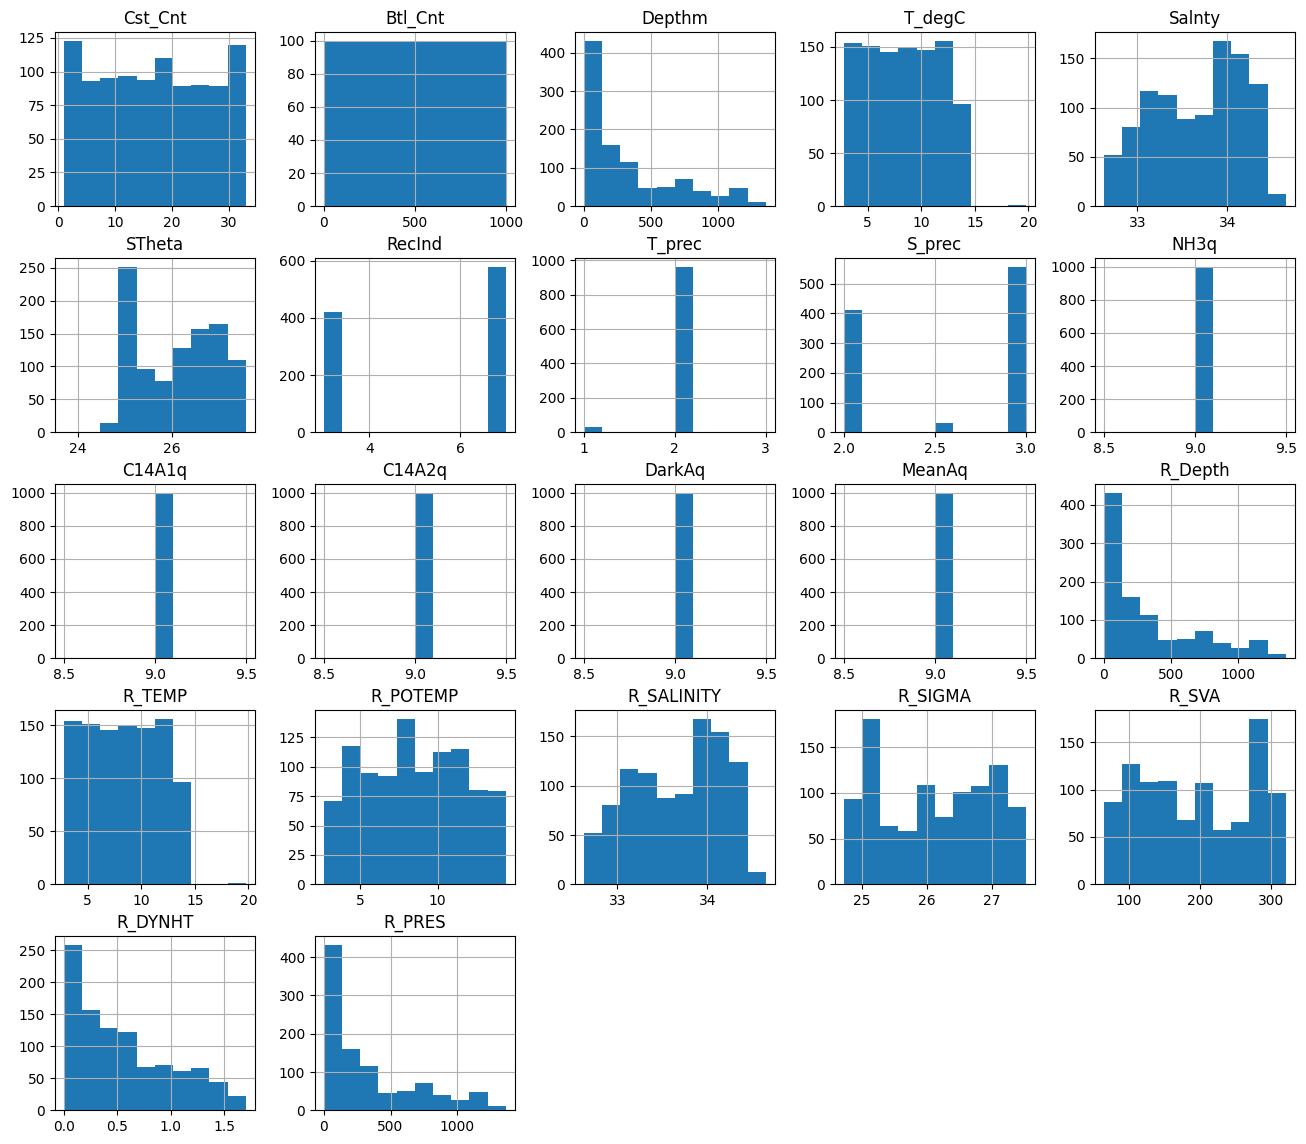

In [ ]:
### Histograms
#sns.histplot(df2)
df2.hist(figsize = (16,14))
plt.show()

# Machine Learning

## Simple Linear Regression

In [ ]:
def create_base(df2):
    # get the dependent, independent data
    X = df2[["Salnty"]]
    y = df2[["T_degC"]]
    assert X.shape == y.shape
    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)
    assert X_train.shape == y_train.shape
    #scaling to bring whole data to the same scale
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.fit_transform(X_test)
    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = create_base(df2)

### Simple Linear Regression Initialize

In [ ]:
def model(X_train, X_test, y_train, y_test):
    #initialize linear regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    # prediction
    y_hat = lr.predict(X_test)
    #printing the results
    print("y_hat results")
    print(f"{y_hat[0:5]}")
    print("---------------------------------------")
    print(f"intercept is {lr.intercept_}")
    print("---------------------------------------")
    print(f"coefis {lr.coef_}")
    # Model accuracy and R squared value
    print("---------------------------------------")
    print("Linear Regression Model accuracy: " +"{:.2%}".format(lr.score(X_test, y_test)))
    print("---------------------------------------")
    print("R_Square Score: " +"{:.4}".format(r2_score(y_test, y_hat)))
    #MAE, MSE and RMSE for Simple Linear Regression
    print("---------------------------------------")
    print("Mean Absolute Error: " +"{:.4}".format(mean_absolute_error(y_test, y_hat)))
    print("---------------------------------------")
    print("Mean Squared Error: " +"{:.4}".format(mean_squared_error(y_test, y_hat)))
    print("---------------------------------------")
    print("RMSE: " +"{:.4}".format(np.sqrt(mean_squared_error(y_test, y_hat))))
    return lr

In [ ]:
lr = model(X_train, X_test, y_train, y_test)

y_hat results
[[ 5.10476739]
 [10.79448247]
 [10.66575588]
 [ 7.85951632]
 [12.82836252]]
---------------------------------------
intercept is [8.39930914]
---------------------------------------
coefis [[-2.66292264]]
---------------------------------------
Linear Regression Model accuracy: 68.10%
---------------------------------------
R_Square Score: 0.681
---------------------------------------
Mean Absolute Error: 1.416
---------------------------------------
Mean Squared Error: 3.58
---------------------------------------
RMSE: 1.892


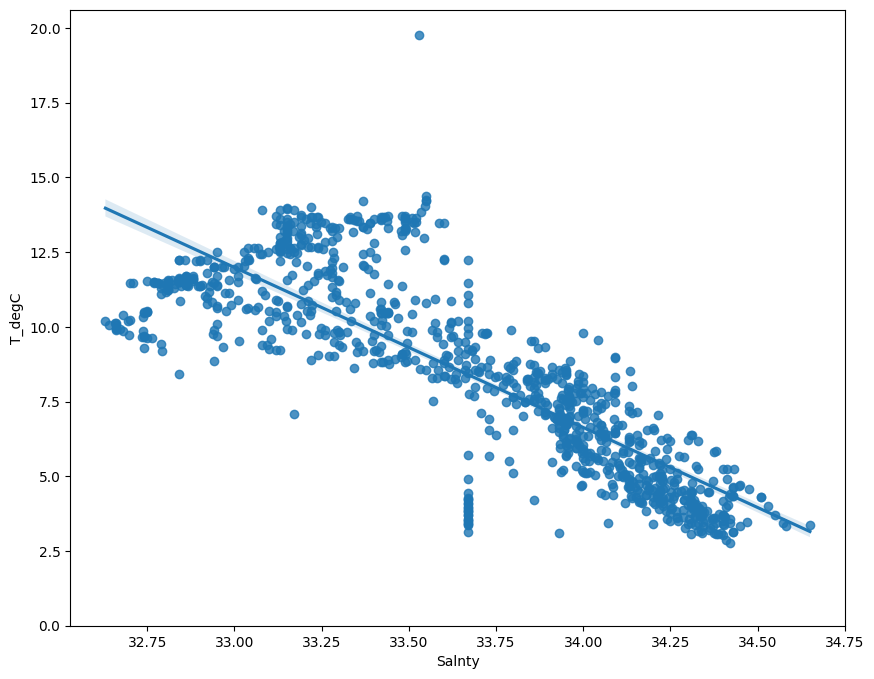

In [ ]:
# Plot the best fit line (SNS Library plot)
plt.figure(figsize=(10, 8))
# regression plot = scatter + fitline
sns.regplot(x=df2["Salnty"], y=df2["T_degC"], data=df2)
plt.ylim(0,);

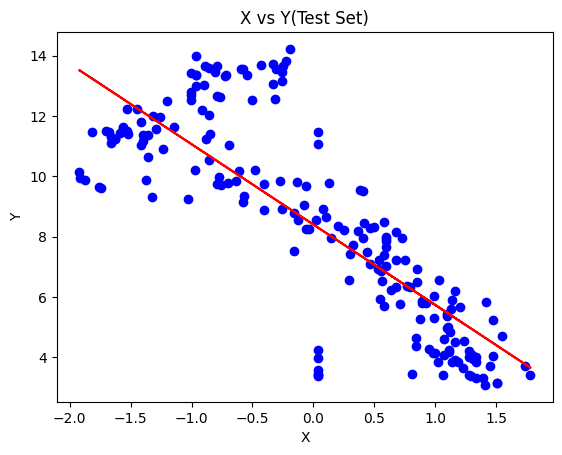

In [ ]:
### Plot the best fit line (matplotlib plot)
plt.scatter(X_test,y_test,color='blue')
plt.plot(X_test,lr.predict(X_test),color='red')
plt.title('X vs Y(Test Set)')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
### Regression using Polynomial Features
pr = PolynomialFeatures(degree=3)
X_train_pr = pr.fit_transform(X_train)
X_test_pr = pr.fit_transform(X_test)
pr
print(X_train_pr.shape)
print(X_test_pr.shape)

(800, 4)
(200, 4)


In [ ]:
model(X_train_pr,X_test_pr, y_train, y_test)

y_hat results
[[ 4.48483015]
 [11.78699953]
 [11.71363774]
 [ 8.33527062]
 [11.30019929]]
---------------------------------------
intercept is [9.15608819]
---------------------------------------
coefis [[ 0.         -3.95212109 -0.60118508  0.601188  ]]
---------------------------------------
Linear Regression Model accuracy: 77.63%
---------------------------------------
R_Square Score: 0.7763
---------------------------------------
Mean Absolute Error: 1.124
---------------------------------------
Mean Squared Error: 2.511
---------------------------------------
RMSE: 1.585


LinearRegression()

In [ ]:
### Define a function to plot the Non-Linear Regression line
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):

    plt.figure(figsize=(12, 10))

    #training data
    #testing data
    # lr:  linear regression object
    #poly_transform:  polynomial transformation object

    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')

    plt.ylabel('Temperature')
    plt.legend()

In [ ]:
X_test = pd.DataFrame(X_test)
X_train = pd.DataFrame(X_train)
y_test = pd.DataFrame(y_test)
y_train = pd.DataFrame(y_train)

### Visualization

In [ ]:
lr_poly= LinearRegression()
lr_poly.fit(X_train_pr, y_train)

LinearRegression()

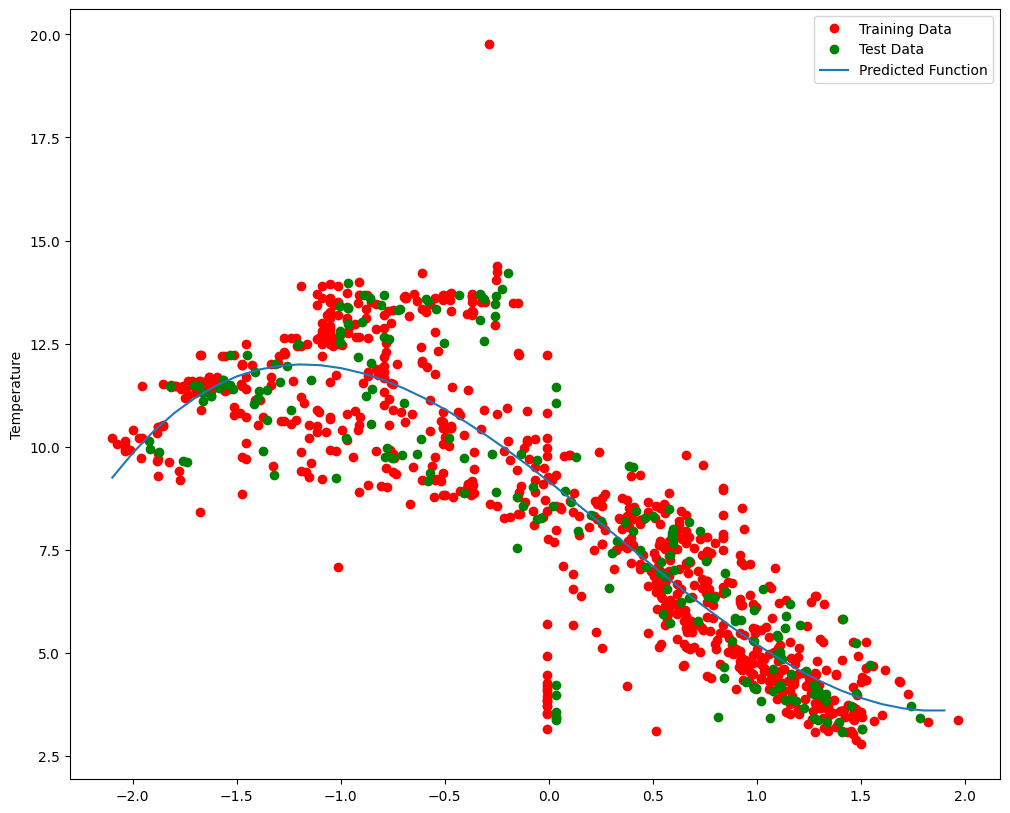

In [ ]:
PollyPlot(X_train, X_test, y_train, y_test, lr_poly,pr)

In [ ]:
X = df2[["Salnty"]]
y = df2[["T_degC"]]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)
print(X.shape)
print(y.shape)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

(1000, 1)
(1000, 1)
Train set: (800, 1) (800, 1)
Test set: (200, 1) (200, 1)


### Create a Pipeline to streamline the entire process

In [ ]:
Operations =[('scale',StandardScaler()), ('polynomial', PolynomialFeatures()), ('linear',LinearRegression())]
pipe = Pipeline(Operations)
pipe.fit(X_train,y_train)
y_hat_pipe = pipe.predict(X_test)

In [ ]:
### Display the parameters for the pipeline
sorted(pipe.get_params().keys())

['linear',
 'linear__copy_X',
 'linear__fit_intercept',
 'linear__n_jobs',
 'linear__positive',
 'memory',
 'polynomial',
 'polynomial__degree',
 'polynomial__include_bias',
 'polynomial__interaction_only',
 'polynomial__order',
 'scale',
 'scale__copy',
 'scale__with_mean',
 'scale__with_std',
 'steps',
 'verbose']

In [ ]:
### GridSearch CV using 10 folds
parameters = {'polynomial__degree': np.arange(5)}

pipe_grid = GridSearchCV(pipe, param_grid = parameters, cv=10,n_jobs = -1)
pipe_grid.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('polynomial', PolynomialFeatures()),
                                       ('linear', LinearRegression())]),
             n_jobs=-1,
             param_grid={'polynomial__degree': array([0, 1, 2, 3, 4])})

In [ ]:
### Obtain the best parameters
#best_params_ attributu vasitesile en yaxshi parametrlerin tapilmasi
print(pipe_grid.best_params_)

{'polynomial__degree': 3}


In [ ]:
### Cross Validation Score
Rcross = cross_val_score(pipe, X, y, cv=10)
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

The mean of the folds are 0.7411360367243331 and the standard deviation is 0.15632166215805823


In [ ]:
-1 * cross_val_score(pipe,X, y,cv=10,scoring='neg_mean_squared_error')

array([1.65323064, 1.40905334, 1.48620657, 1.01784319, 0.62977105,
       2.70299074, 5.71261877, 1.61551808, 6.90181317, 4.64129707])

In [ ]:
### Redefine the pipeline with best parameters
Operations =[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(degree=3)), ('linear',LinearRegression())]
pipe = Pipeline(Operations)
pipe.fit(X_train,y_train)
y_hat_pipe = pipe.predict(X_test)

In [ ]:
### Display the metrics
print("R_Square Score: " +"{:.4}".format(r2_score(y_test, y_hat_pipe)))

R_Square Score: 0.778


In [ ]:
### MAE, MSE and RMSE for Pipeline
print("Mean Absolute Error: " +"{:.4}".format(mean_absolute_error(y_test, y_hat_pipe)))
print("Mean Squared Error: " +"{:.4}".format(mean_squared_error(y_test, y_hat_pipe)))
print("RMSE: " +"{:.4}".format(np.sqrt(mean_squared_error(y_test, y_hat_pipe))))

Mean Absolute Error: 1.124
Mean Squared Error: 2.492
RMSE: 1.578
